In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/mta_cleaned.csv")
df["month"] = pd.to_datetime(df["month"])
PRE_END = pd.Timestamp("2020-03-20")      
COVID_END = pd.Timestamp("2021-05-17")    

def assign_phase(dt):
    if dt < PRE_END:
        return "pre_covid"
    elif dt <= COVID_END:
        return "covid"
    else:
        return "recovery"

df["phase"] = df["month"].apply(assign_phase)
df[["month", "phase"]].drop_duplicates().sort_values("month").head(15)



,month,phase
0,2020-01-01,pre_covid
48,2020-02-01,pre_covid
96,2020-03-01,pre_covid
144,2020-04-01,covid
184,2020-05-01,covid
226,2020-06-01,covid
272,2020-07-01,covid
318,2020-08-01,covid
366,2020-09-01,covid
414,2020-10-01,covid


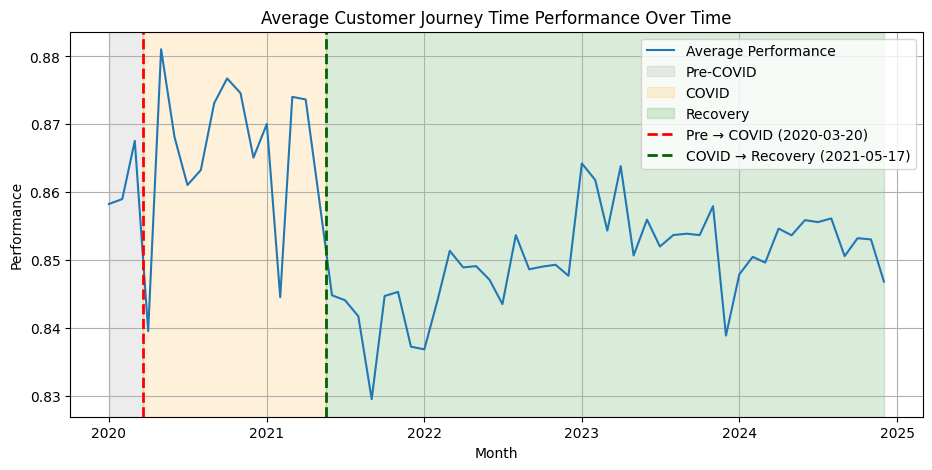

In [3]:
monthly_perf = df.groupby("month")["customer journey time performance"].mean()

plt.figure(figsize=(11, 5))
plt.plot(
    monthly_perf.index,
    monthly_perf.values,
    label="Average Performance"
)

plt.axvspan(
    monthly_perf.index.min(),
    PRE_END,
    alpha=0.15,
    color="gray",
    label="Pre-COVID"
)

plt.axvspan(
    PRE_END,
    COVID_END,
    alpha=0.15,
    color="orange",
    label="COVID"
)

plt.axvspan(
    COVID_END,
    monthly_perf.index.max(),
    alpha=0.15,
    color="green",
    label="Recovery"
)

plt.axvline(
    PRE_END,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Pre → COVID (2020-03-20)"
)

plt.axvline(
    COVID_END,
    color="darkgreen",
    linestyle="--",
    linewidth=2,
    label="COVID → Recovery (2021-05-17)"
)

plt.title("Average Customer Journey Time Performance Over Time")
plt.xlabel("Month")
plt.ylabel("Performance")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
phase_summary = (
    df.groupby("phase")["customer journey time performance"]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)

phase_summary

,count,mean,median,std
phase,,,,
covid,652,0.866214,0.862699,0.052801
pre_covid,144,0.861597,0.850300,0.052885
recovery,2060,0.849901,0.847209,0.061827


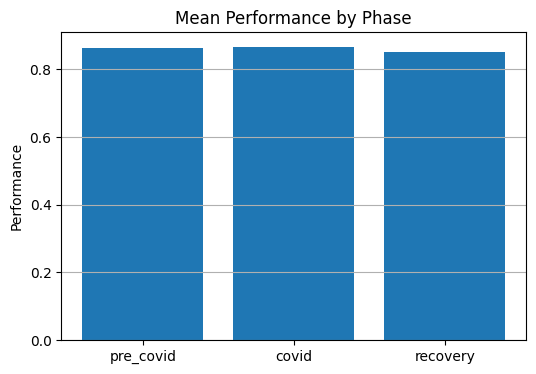

In [5]:
pre = df[df["phase"] == "pre_covid"]["customer journey time performance"]
cov = df[df["phase"] == "covid"]["customer journey time performance"]
rec = df[df["phase"] == "recovery"]["customer journey time performance"]

pre.mean(), cov.mean(), rec.mean()

means = df.groupby("phase")["customer journey time performance"].mean().reindex(["pre_covid","covid","recovery"])

plt.figure(figsize=(6,4))
plt.bar(means.index, means.values)
plt.title("Mean Performance by Phase")
plt.ylabel("Performance")
plt.grid(axis="y")
plt.show()

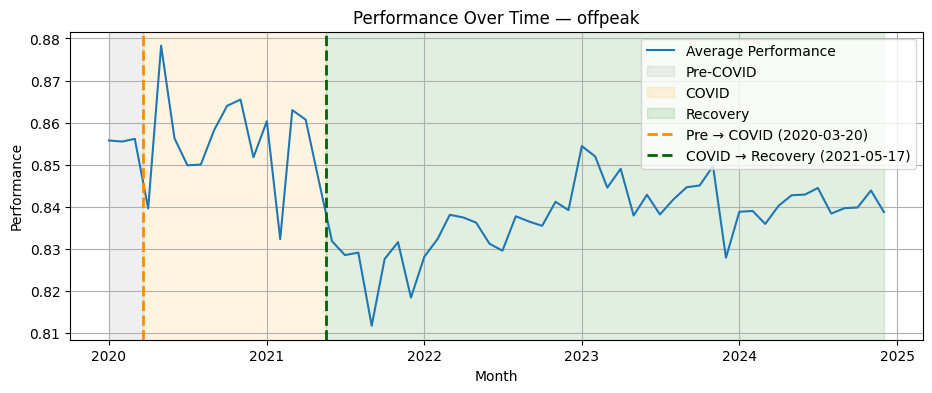

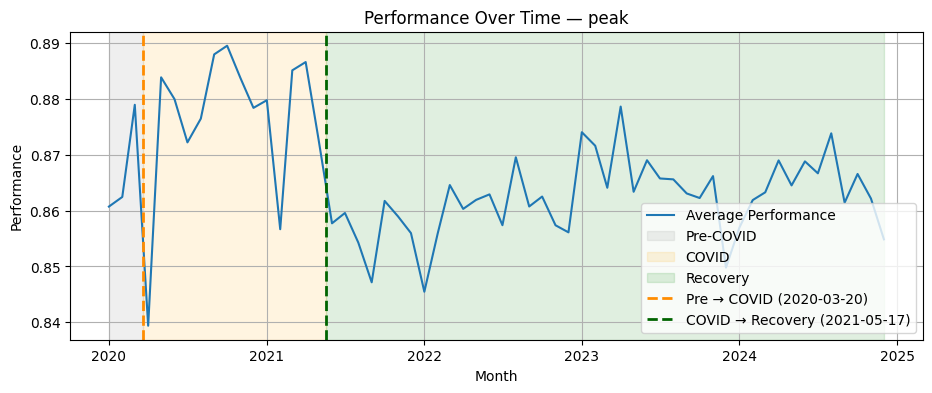

In [6]:
tmp = (
    df.groupby(["month", "period"])["customer journey time performance"]
    .mean()
    .reset_index()
)
tmp["phase"] = tmp["month"].apply(assign_phase)

for period in tmp["period"].unique():
    subset = tmp[tmp["period"] == period]

    plt.figure(figsize=(11, 4))

    # Main trend line
    plt.plot(
        subset["month"],
        subset["customer journey time performance"],
        label="Average Performance"
    )

    # Shaded phases
    plt.axvspan(
        subset["month"].min(),
        PRE_END,
        alpha=0.12,
        color="gray",
        label="Pre-COVID"
    )
    plt.axvspan(
        PRE_END,
        COVID_END,
        alpha=0.12,
        color="orange",
        label="COVID"
    )
    plt.axvspan(
        COVID_END,
        subset["month"].max(),
        alpha=0.12,
        color="green",
        label="Recovery"
    )

    # Cutoff lines (non-blue)
    plt.axvline(
        PRE_END,
        color="darkorange",
        linestyle="--",
        linewidth=2,
        label="Pre → COVID (2020-03-20)"
    )
    plt.axvline(
        COVID_END,
        color="darkgreen",
        linestyle="--",
        linewidth=2,
        label="COVID → Recovery (2021-05-17)"
    )

    plt.title(f"Performance Over Time — {period}")
    plt.xlabel("Month")
    plt.ylabel("Performance")
    plt.legend()
    plt.grid(True)
    plt.show()

In [7]:
phase_period = (
    df.groupby(["phase", "period"])["customer journey time performance"]
    .mean()
    .reset_index()
)

phase_period

,phase,period,customer journey time performance
0,covid,offpeak,0.855462
1,covid,peak,0.876966
2,pre_covid,offpeak,0.855832
3,pre_covid,peak,0.867362
4,recovery,offpeak,0.837613
5,recovery,peak,0.862188


In [8]:
phase_line_type = (
    df.groupby(["phase", "line_type"])["customer journey time performance"]
    .mean()
    .reset_index()
)

phase_line_type

,phase,line_type,customer journey time performance
0,covid,COMBINED,0.834733
1,covid,LETTER,0.841294
2,covid,NUMBER,0.882630
3,covid,SHUTTLE,0.953856
4,pre_covid,COMBINED,0.826672
5,pre_covid,LETTER,0.830118
6,pre_covid,NUMBER,0.884786
7,pre_covid,SHUTTLE,0.955540
8,recovery,COMBINED,0.815914
9,recovery,LETTER,0.815543


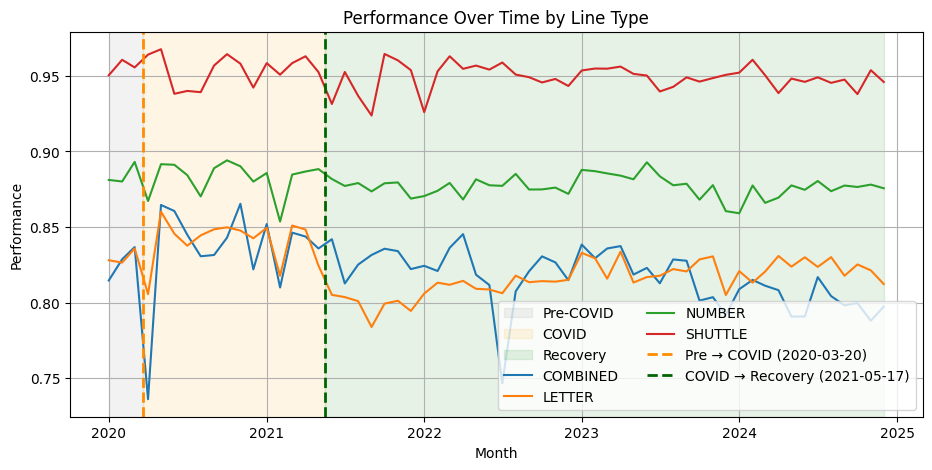

In [9]:
lt_month = (
    df.groupby(["month", "line_type"])["customer journey time performance"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(11,5))

# Shaded phases
plt.axvspan(
    lt_month["month"].min(),
    PRE_END,
    alpha=0.10,
    color="gray",
    label="Pre-COVID"
)
plt.axvspan(
    PRE_END,
    COVID_END,
    alpha=0.10,
    color="orange",
    label="COVID"
)
plt.axvspan(
    COVID_END,
    lt_month["month"].max(),
    alpha=0.10,
    color="green",
    label="Recovery"
)

# Line-type trends
for lt in lt_month["line_type"].unique():
    sub = lt_month[lt_month["line_type"] == lt]
    plt.plot(
        sub["month"],
        sub["customer journey time performance"],
        label=lt
    )

# Cutoff lines (non-blue)
plt.axvline(
    PRE_END,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label="Pre → COVID (2020-03-20)"
)
plt.axvline(
    COVID_END,
    color="darkgreen",
    linestyle="--",
    linewidth=2,
    label="COVID → Recovery (2021-05-17)"
)

plt.title("Performance Over Time by Line Type")
plt.xlabel("Month")
plt.ylabel("Performance")
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [10]:
recovery_df = df[df["phase"] == "recovery"].copy()

recovery_df["month_index"] = (
    (recovery_df["month"] - COVID_END).dt.days / 30.44
)

# overall recovery slope
slope, intercept = np.polyfit(
    recovery_df["month_index"],
    recovery_df["customer journey time performance"],
    1
)

slope



np.float64(0.00028890880385218744)

In [11]:
slopes = {}

for lt in recovery_df["line_type"].unique():
    sub = recovery_df[recovery_df["line_type"] == lt]
    if len(sub) > 5:
        s, _ = np.polyfit(sub["month_index"], sub["customer journey time performance"], 1)
        slopes[lt] = s

slopes

{'NUMBER': np.float64(-7.163466926362819e-05),
 'SHUTTLE': np.float64(-1.781888300275298e-05),
 'LETTER': np.float64(0.0006012711997771948),
 'COMBINED': np.float64(-0.0007474464045920913)}

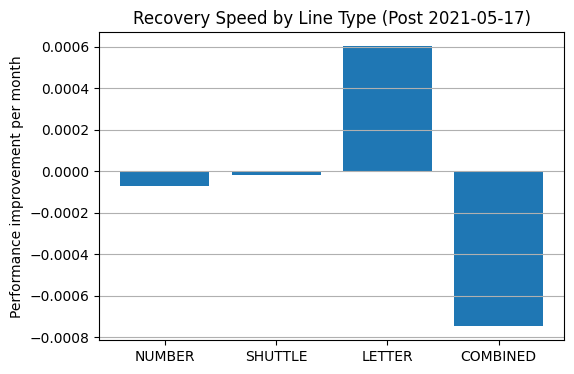

In [12]:
plt.figure(figsize=(6,4))
plt.bar(list(slopes.keys()), list(slopes.values()))
plt.title("Recovery Speed by Line Type (Post 2021-05-17)")
plt.ylabel("Performance improvement per month")
plt.grid(axis="y")
plt.show()

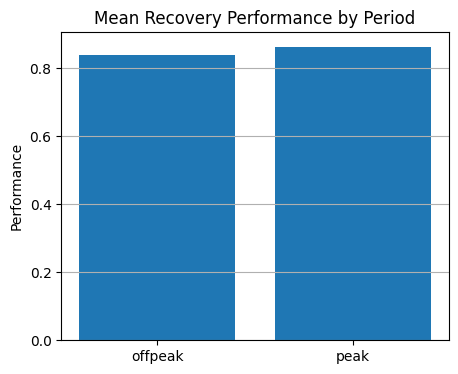

In [13]:
rec_period = recovery_df.groupby("period")["customer journey time performance"].mean()
rec_period

plt.figure(figsize=(5,4))
plt.bar(rec_period.index, rec_period.values)
plt.title("Mean Recovery Performance by Period")
plt.ylabel("Performance")
plt.grid(axis="y")
plt.show()



In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# 1) Load data
# -----------------------------
DATA_PATH = "../data/mta_cleaned.csv"  
df = pd.read_csv(DATA_PATH)

# Make sure month is datetime
df["month"] = pd.to_datetime(df["month"])

# -----------------------------
# 2) Define phase cutoffs
# -----------------------------
PRE_END = pd.Timestamp("2020-03-20")
COVID_END = pd.Timestamp("2021-05-17")

def assign_phase(dt):
    if dt < PRE_END:
        return "pre_covid"
    elif dt <= COVID_END:
        return "covid"
    else:
        return "recovery"

df["phase"] = df["month"].apply(assign_phase)

# -----------------------------
# 3) Recovery-only dataset + month_index feature
# -----------------------------

# months since COVID_END (approx)
df["month_index"] = (df["month"] - COVID_END).dt.days / 30.44

# -----------------------------
# 4) Build features (X) and target (y)
# -----------------------------
target = "customer journey time performance"

features = [
    "month_index",        # numeric
    "num_passengers",     # numeric
    "period",             # categorical (peak/offpeak)
    "line_type",          # categorical (your engineered feature)
    "division"            # categorical (A DIVISION / B DIVISION)
]

df_model = df[df["phase"].isin(["covid", "recovery"])][
    features + ["customer journey time performance", "phase"]
]

df_encoded = pd.get_dummies(
    df_model,
    columns=["period", "line_type", "division"],
    drop_first=True
)

def fit_phase_model(df_phase, target_col=target, test_size=0.25, random_state=42):
    X = df_phase.drop(columns=[target_col])
    y = df_phase[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return {
        "model": model,
        "rows_used": len(df_phase),
        "n_features": X.shape[1],
        "r2": r2_score(y_test, y_pred),
        "mse": mean_squared_error(y_test, y_pred),
        "coefficients": pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
    }

covid_df = df_encoded[df_encoded["phase"] == "covid"].drop(columns=["phase"])
recovery_df = df_encoded[df_encoded["phase"] == "recovery"].drop(columns=["phase"])

covid_results = fit_phase_model(covid_df)
recovery_results = fit_phase_model(recovery_df)

# -----------------------------
# 6) Print performance + compare coefficients
# -----------------------------
print("---- Model Performance ----")
print(f"COVID rows used: {covid_results['rows_used']}, features: {covid_results['n_features']}, "
      f"R²: {covid_results['r2']:.4f}, MSE: {covid_results['mse']:.6f}")
print(f"Recovery rows used: {recovery_results['rows_used']}, features: {recovery_results['n_features']}, "
      f"R²: {recovery_results['r2']:.4f}, MSE: {recovery_results['mse']:.6f}")

coef_compare = pd.DataFrame({
    "COVID": covid_results["coefficients"],
    "Recovery": recovery_results["coefficients"]
}).fillna(0)

coef_compare["Change (Recovery - COVID)"] = coef_compare["Recovery"] - coef_compare["COVID"]

coef_compare

---- Model Performance ----
COVID rows used: 652, features: 7, R²: 0.5331, MSE: 0.001380
Recovery rows used: 2060, features: 7, R²: 0.6584, MSE: 0.001328


,COVID,Recovery,Change (Recovery - COVID)
division_B DIVISION,-2.363864e-02,-4.579043e-02,-2.215180e-02
line_type_LETTER,9.930446e-03,4.840541e-03,-5.089905e-03
line_type_NUMBER,2.561427e-02,2.092578e-02,-4.688496e-03
line_type_SHUTTLE,1.093441e-01,1.153695e-01,6.025369e-03
month_index,8.031961e-05,3.292579e-04,2.489383e-04
num_passengers,-2.322505e-09,-3.041374e-09,-7.188693e-10
period_peak,2.442828e-02,2.560986e-02,1.181585e-03


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Load data
# -----------------------------
DATA_PATH = "../data/mta_cleaned.csv"
df = pd.read_csv(DATA_PATH)

df["month"] = pd.to_datetime(df["month"])

# -----------------------------
# 2) Phase cutoffs (your definitions)
# -----------------------------
PRE_END = pd.Timestamp("2020-03-20")
COVID_END = pd.Timestamp("2021-05-17")

def assign_phase(dt):
    if dt < PRE_END:
        return "pre_covid"
    elif dt <= COVID_END:
        return "covid"
    else:
        return "recovery"

df["phase"] = df["month"].apply(assign_phase)

# -----------------------------
# 3) Ensure line is cleaned + line_type exists (if your cleaned file already has these, it's safe)
# -----------------------------
if "line_clean" not in df.columns:
    df["line_clean"] = (
        df["line"].astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.upper()
    )
    shuttle_map = {
        "S42ND": "S_42ND",
        "SFKLN": "S_FKLN",
        "SROCK": "S_ROCK",
    }
    df["line_clean"] = df["line_clean"].replace(shuttle_map)

if "line_type" not in df.columns:
    def line_type(x):
        if str(x).isdigit():
            return "NUMBER"
        if str(x).startswith("S"):
            return "SHUTTLE"
        if str(x) in ["JZ", "NQ", "RW"]:  # keep consistent with your earlier logic if needed
            return "COMBINED"
        return "LETTER"

    df["line_type"] = df["line_clean"].apply(line_type)

# -----------------------------
# 4) Set target metric
# -----------------------------
TARGET = "customer journey time performance"

# -----------------------------
# 5) Primary Analysis: Recovery slope per line
#     - For each line_clean, fit y = a + b*(month_index)
#     - slope b = monthly change in performance
# -----------------------------
recovery_df = df[df["phase"] == "recovery"].copy()
recovery_df["month_index"] = (recovery_df["month"] - COVID_END).dt.days / 30.44

# Minimum number of recovery months needed to compute a meaningful slope
MIN_RECOVERY_POINTS = 12

line_slopes = []
for line_name, g in recovery_df.groupby("line_clean"):
    g = g.dropna(subset=["month_index", TARGET]).sort_values("month_index")
    if len(g) < MIN_RECOVERY_POINTS:
        continue

    # linear fit
    slope, intercept = np.polyfit(g["month_index"], g[TARGET], 1)

    # helpful summary stats
    start_val = g.iloc[0][TARGET]
    end_val = g.iloc[-1][TARGET]
    net_change = end_val - start_val

    line_slopes.append({
        "line_clean": line_name,
        "n_points": len(g),
        "slope_per_month": slope,
        "intercept": intercept,
        "start_month": g.iloc[0]["month"],
        "end_month": g.iloc[-1]["month"],
        "start_perf": start_val,
        "end_perf": end_val,
        "net_change": net_change
    })

slopes_df = pd.DataFrame(line_slopes).sort_values("slope_per_month", ascending=False)

# -----------------------------
# 6) Supporting Analysis: Pre-COVID vs Recovery gap per line
#     - Compare mean performance in each phase (pre_covid vs recovery)
# -----------------------------
phase_means = (
    df[df["phase"].isin(["pre_covid", "recovery"])]
    .groupby(["line_clean", "phase"])[TARGET]
    .mean()
    .unstack()
)

# Optional: require at least some pre-covid data too
pre_counts = df[df["phase"] == "pre_covid"].groupby("line_clean")[TARGET].count()
rec_counts = df[df["phase"] == "recovery"].groupby("line_clean")[TARGET].count()

phase_means["pre_count"] = pre_counts
phase_means["recovery_count"] = rec_counts

# You can adjust these thresholds depending on how strict you want to be
MIN_PRE_POINTS = 2
MIN_REC_POINTS_FOR_GAP = 12

phase_means = phase_means[
    (phase_means["pre_count"] >= MIN_PRE_POINTS) &
    (phase_means["recovery_count"] >= MIN_REC_POINTS_FOR_GAP)
].copy()

phase_means["gap_recovery_minus_pre"] = phase_means["recovery"] - phase_means["pre_covid"]

gaps_df = phase_means.sort_values("gap_recovery_minus_pre", ascending=False)

# -----------------------------
# 7) Outputs (tables)
# -----------------------------
print("\n===== PRIMARY: Recovery slope per line (monthly trend) =====")
print(slopes_df.head(15))


===== PRIMARY: Recovery slope per line (monthly trend) =====
   line_clean  n_points  slope_per_month  intercept start_month  end_month  \
11          E        86         0.001930   0.790593  2021-06-01 2024-12-01   
9           C        86         0.001183   0.779269  2021-06-01 2024-12-01   
23          W        86         0.000743   0.868278  2021-06-01 2024-12-01   
7           A        86         0.000724   0.787110  2021-06-01 2024-12-01   
16          M        86         0.000675   0.778598  2021-06-01 2024-12-01   
10          D        86         0.000588   0.751766  2021-06-01 2024-12-01   
17          N        86         0.000573   0.793831  2021-06-01 2024-12-01   
6           7        86         0.000555   0.874469  2021-06-01 2024-12-01   
18          Q        86         0.000528   0.780470  2021-06-01 2024-12-01   
20     S_42ND        82         0.000489   0.970852  2021-06-01 2024-12-01   
19          R        86         0.000468   0.790945  2021-06-01 2024-12-01   
8 

In [22]:
print("\n===== PRIMARY: Worst recovery slopes (declining / slow improving) =====")
print(slopes_df.tail(15))


===== PRIMARY: Worst recovery slopes (declining / slow improving) =====
   line_clean  n_points  slope_per_month  intercept start_month  end_month  \
20     S_42ND        82         0.000489   0.970852  2021-06-01 2024-12-01   
19          R        86         0.000468   0.790945  2021-06-01 2024-12-01   
8           B        86         0.000362   0.755617  2021-06-01 2024-12-01   
13          G        86         0.000297   0.818311  2021-06-01 2024-12-01   
3           4        86         0.000267   0.865019  2021-06-01 2024-12-01   
12          F        86         0.000247   0.807314  2021-06-01 2024-12-01   
4           5        86         0.000055   0.868287  2021-06-01 2024-12-01   
22     S_ROCK        86        -0.000134   0.905624  2021-06-01 2024-12-01   
2           3        86        -0.000150   0.889343  2021-06-01 2024-12-01   
0           1        86        -0.000174   0.890053  2021-06-01 2024-12-01   
15          L        86        -0.000502   0.931952  2021-06-01 2024-

In [23]:
print("\n===== SUPPORTING: Pre-COVID vs Recovery gap per line (mean difference) =====")
print(gaps_df.head(15)[["pre_covid", "recovery", "gap_recovery_minus_pre", "pre_count", "recovery_count"]])



===== SUPPORTING: Pre-COVID vs Recovery gap per line (mean difference) =====
phase       pre_covid  recovery  gap_recovery_minus_pre  pre_count  \
line_clean                                                           
L            0.899103  0.921169                0.022066          6   
S_42ND       0.976794  0.981686                0.004893          6   
S_FKLN       0.962047  0.964031                0.001984          6   
5            0.868650  0.869468                0.000817          6   
4            0.870439  0.870752                0.000313          6   
G            0.826052  0.824701               -0.001351          6   
7            0.889677  0.886401               -0.003276          6   
W            0.888864  0.884255               -0.004609          6   
2            0.866460  0.857576               -0.008884          6   
1            0.896072  0.886321               -0.009751          6   
E            0.841997  0.832078               -0.009919          6   
N           

In [24]:
print("\n===== SUPPORTING: Worst gaps (most below pre-COVID in recovery) =====")
print(gaps_df.tail(15)[["pre_covid", "recovery", "gap_recovery_minus_pre", "pre_count", "recovery_count"]])


===== SUPPORTING: Worst gaps (most below pre-COVID in recovery) =====
phase       pre_covid  recovery  gap_recovery_minus_pre  pre_count  \
line_clean                                                           
1            0.896072  0.886321               -0.009751          6   
E            0.841997  0.832078               -0.009919          6   
N            0.816412  0.806155               -0.010257          6   
JZ           0.826672  0.815914               -0.010758          6   
A            0.818078  0.802668               -0.015410          6   
6            0.898241  0.880670               -0.017571          6   
3            0.903959  0.886127               -0.017832          6   
M            0.811244  0.793098               -0.018146          6   
B            0.782448  0.763392               -0.019056          6   
Q            0.813117  0.791818               -0.021298          6   
D            0.788631  0.764401               -0.024230          6   
S_ROCK       0.9277

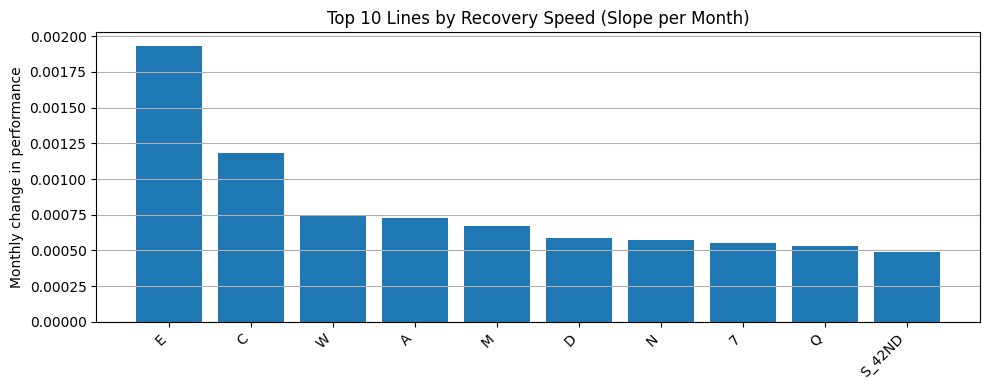

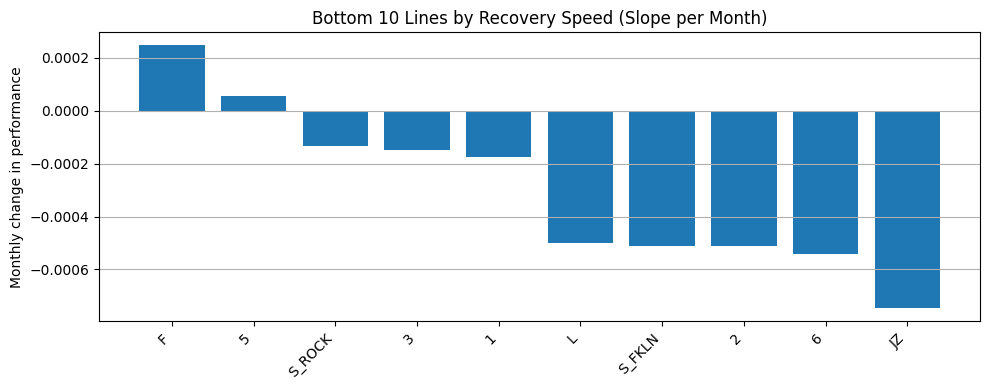

In [25]:
TOP_N = 10

# A) Recovery slopes bar chart
top_slopes = slopes_df.head(TOP_N).set_index("line_clean")["slope_per_month"]
bottom_slopes = slopes_df.tail(TOP_N).set_index("line_clean")["slope_per_month"]

plt.figure(figsize=(10, 4))
plt.bar(top_slopes.index, top_slopes.values)
plt.title(f"Top {TOP_N} Lines by Recovery Speed (Slope per Month)")
plt.ylabel("Monthly change in performance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(bottom_slopes.index, bottom_slopes.values)
plt.title(f"Bottom {TOP_N} Lines by Recovery Speed (Slope per Month)")
plt.ylabel("Monthly change in performance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

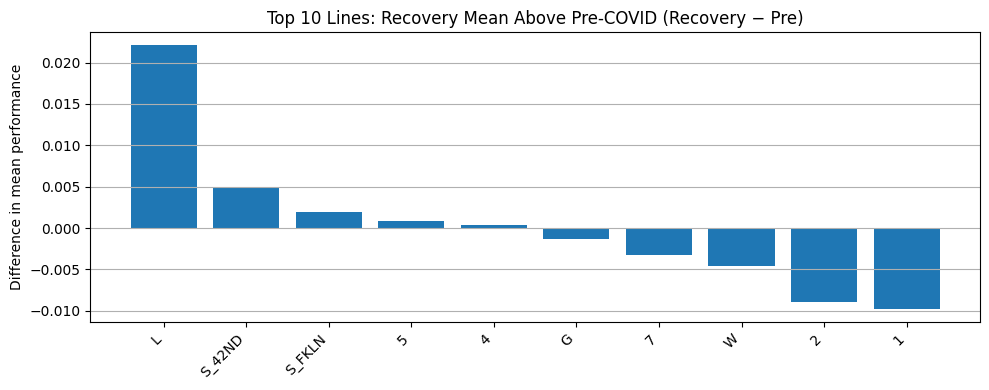

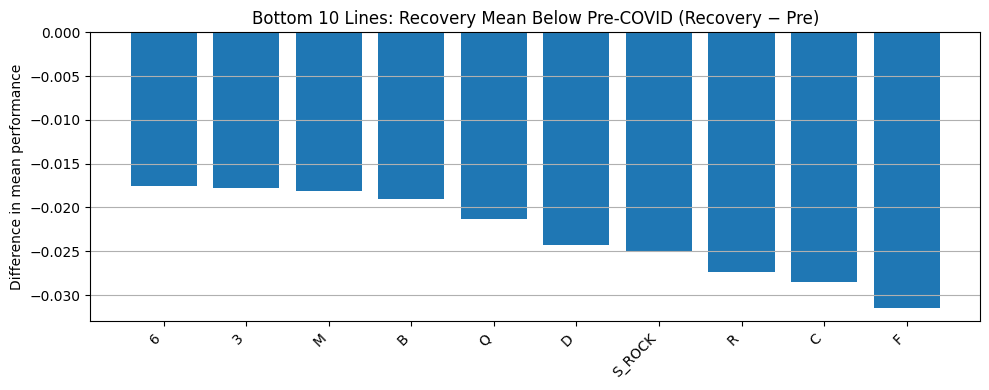

In [26]:
# B) Gap vs pre-COVID bar chart
top_gaps = gaps_df.head(TOP_N).copy()
bottom_gaps = gaps_df.tail(TOP_N).copy()

plt.figure(figsize=(10, 4))
plt.bar(top_gaps.index, top_gaps["gap_recovery_minus_pre"].values)
plt.title(f"Top {TOP_N} Lines: Recovery Mean Above Pre-COVID (Recovery − Pre)")
plt.ylabel("Difference in mean performance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(bottom_gaps.index, bottom_gaps["gap_recovery_minus_pre"].values)
plt.title(f"Bottom {TOP_N} Lines: Recovery Mean Below Pre-COVID (Recovery − Pre)")
plt.ylabel("Difference in mean performance")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()